In [64]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import tensorflow as tf

In [65]:
tf.__version__

'2.10.0'

In [66]:
dataset = pd.read_csv("./datasets/Churn_Modelling.csv")
dataset.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [67]:
X = dataset.iloc[:, 3:-1].values
y = dataset.iloc[:, -1].values

In [68]:
print(X)

[[619 'France' 'Female' ... 1 1 101348.88]
 [608 'Spain' 'Female' ... 0 1 112542.58]
 [502 'France' 'Female' ... 1 0 113931.57]
 ...
 [709 'France' 'Female' ... 0 1 42085.58]
 [772 'Germany' 'Male' ... 1 0 92888.52]
 [792 'France' 'Female' ... 1 0 38190.78]]


In [69]:
print(y)

[1 0 1 ... 1 1 0]


In [70]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [71]:
#checking dataset have any empty row
dataset.isnull().sum()

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

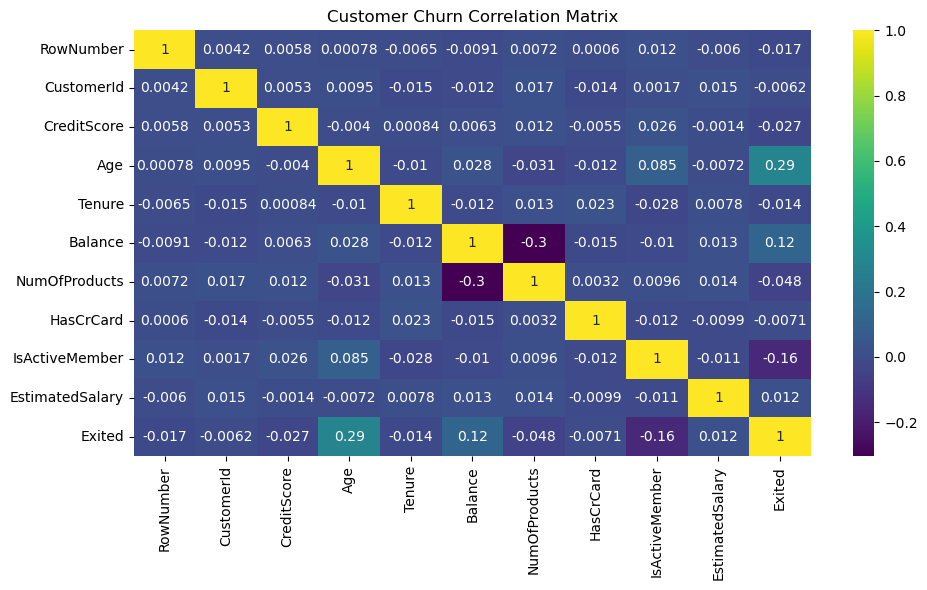

In [72]:
datasetCorr = dataset.drop('Surname', axis=1)
datasetCorr = datasetCorr.drop('Geography', axis=1)
#datasetCorr['Gender_Encoded'] = datasetCorr['Gender'].map({'male': 0, 'female' : 1})
datasetCorr = datasetCorr.drop('Gender', axis=1)
plt.figure(figsize=(10,6))
sns.heatmap(data=datasetCorr.corr(), cmap='viridis', annot=True)
plt.title('Customer Churn Correlation Matrix')
plt.tight_layout()
plt.show()

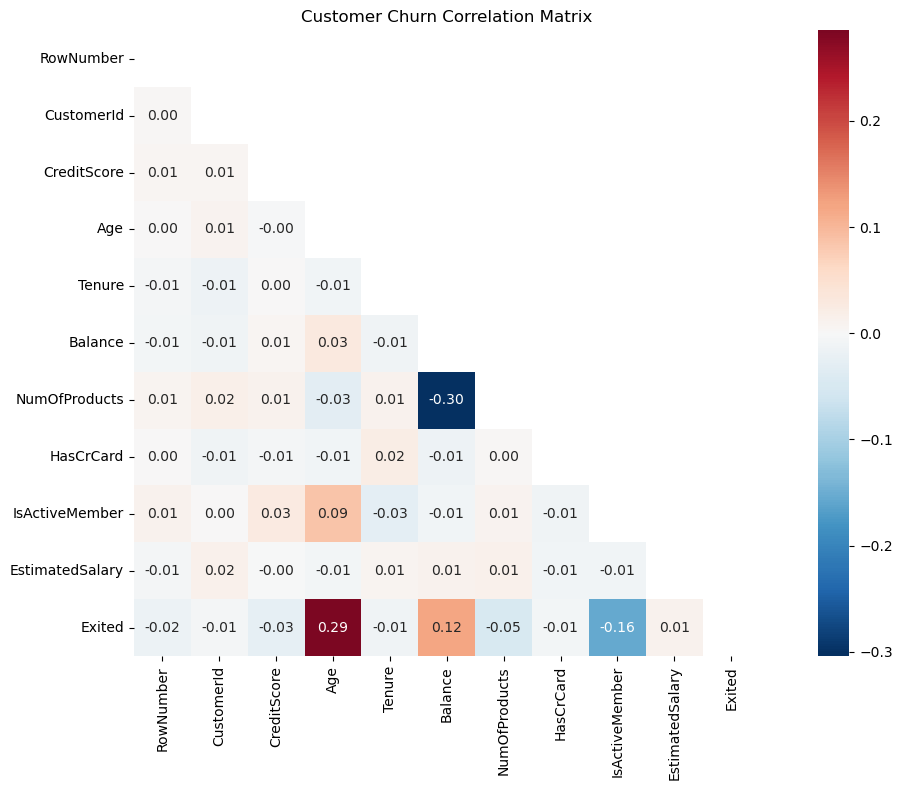

In [73]:
#Better presentable
plt.figure(figsize=(12,8))
mask = np.triu(np.ones_like(datasetCorr.corr(), dtype=bool))  # Upper triangle only
sns.heatmap(datasetCorr.corr(), 
            mask=mask, 
            cmap='RdBu_r',    # Red-Blue (better for ± corr)
            annot=True, 
            center=0,
            square=True,
            fmt='.2f')
plt.title('Customer Churn Correlation Matrix')
plt.tight_layout()
plt.show()

In [74]:
print(X)

[[619 'France' 'Female' ... 1 1 101348.88]
 [608 'Spain' 'Female' ... 0 1 112542.58]
 [502 'France' 'Female' ... 1 0 113931.57]
 ...
 [709 'France' 'Female' ... 0 1 42085.58]
 [772 'Germany' 'Male' ... 1 0 92888.52]
 [792 'France' 'Female' ... 1 0 38190.78]]


In [75]:
#label encoding of gender encoding
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
X[:, 2] = le.fit_transform(X[:, 2])
print(X)

[[619 'France' 0 ... 1 1 101348.88]
 [608 'Spain' 0 ... 0 1 112542.58]
 [502 'France' 0 ... 1 0 113931.57]
 ...
 [709 'France' 0 ... 0 1 42085.58]
 [772 'Germany' 1 ... 1 0 92888.52]
 [792 'France' 0 ... 1 0 38190.78]]


In [76]:
#one hot encoding of geography
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
ct = ColumnTransformer(transformers=[('encoder', OneHotEncoder(), [1])], remainder='passthrough')
X = np.array(ct.fit_transform(X))

In [77]:
print(X)

[[1.0 0.0 0.0 ... 1 1 101348.88]
 [0.0 0.0 1.0 ... 0 1 112542.58]
 [1.0 0.0 0.0 ... 1 0 113931.57]
 ...
 [1.0 0.0 0.0 ... 0 1 42085.58]
 [0.0 1.0 0.0 ... 1 0 92888.52]
 [1.0 0.0 0.0 ... 1 0 38190.78]]


In [78]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

In [79]:
#Feature Scaling
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.fit_transform(X_test)

#Building ANN

In [80]:
#Building the ANN
#initialize the ANN
ann = tf.keras.Sequential()

In [81]:
#adding input layer and the first hidden layer
ann.add(tf.keras.layers.Dense(units=6, activation='relu'))

In [82]:
#adding second layer
ann.add(tf.keras.layers.Dense(units=6, activation='relu'))

In [83]:
#add output layer
ann.add(tf.keras.layers.Dense(units=1, activation='sigmoid'))

In [84]:
#Training the brain
#compiling
ann.compile(optimizer= 'adam',loss= 'binary_crossentropy',metrics= ['accuracy'])


In [85]:
ann.fit(X_train, y_train, batch_size=32, epochs=100)

Epoch 1/100
250/250 [==============================] - 1s 1ms/step - loss: 0.5082 - accuracy: 0.7829
Epoch 2/100
250/250 [==============================] - 0s 2ms/step - loss: 0.4527 - accuracy: 0.7994
Epoch 3/100
250/250 [==============================] - 0s 2ms/step - loss: 0.4358 - accuracy: 0.8045
Epoch 4/100
250/250 [==============================] - 0s 2ms/step - loss: 0.4246 - accuracy: 0.8091
Epoch 5/100
250/250 [==============================] - 0s 2ms/step - loss: 0.4097 - accuracy: 0.8184
Epoch 6/100
250/250 [==============================] - 0s 2ms/step - loss: 0.3945 - accuracy: 0.8291
Epoch 7/100
250/250 [==============================] - 0s 2ms/step - loss: 0.3834 - accuracy: 0.8330
Epoch 8/100
250/250 [==============================] - 0s 2ms/step - loss: 0.3757 - accuracy: 0.8374
Epoch 9/100
250/250 [==============================] - 0s 2ms/step - loss: 0.3702 - accuracy: 0.8410
Epoch 10/100
250/250 [==============================] - 0s 2ms/step - loss: 0.3664 - accura

In [86]:
#predicting result
print(ann.predict(sc.transform([[1, 0, 0, 600, 1, 40, 3, 60000, 2, 1, 1, 50000]])) > 0.5)

1/1 [==============================] - 0s 262ms/step
[[False]]


Therefore, our ANN model predicts that this customer stays in the bank!

**Important note 1:** Notice that the values of the features were all input in a double pair of square brackets. That's because the "predict" method always expects a 2D array as the format of its inputs. And putting our values into a double pair of square brackets makes the input exactly a 2D array.

**Important note 2:** Notice also that the "France" country was not input as a string in the last column but as "1, 0, 0" in the first three columns. That's because of course the predict method expects the one-hot-encoded values of the state, and as we see in the first row of the matrix of features X, "France" was encoded as "1, 0, 0". And be careful to include these values in the first three columns, because the dummy variables are always created in the first columns.

In [87]:
y_pred = ann.predict(X_test)
y_pred = (y_pred > 0.5)
print(np.concatenate((y_pred.reshape(len(y_pred),1), y_test.reshape(len(y_test),1)),1))

63/63 [==============================] - 0s 1ms/step
[[0 0]
 [0 1]
 [0 0]
 ...
 [0 0]
 [0 0]
 [0 0]]


In [89]:
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
cm = confusion_matrix(y_test, y_pred)
print(cm)
accuracy_score(y_test, y_pred)

[[1532   63]
 [ 210  195]]


0.8635

In [90]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.88      0.96      0.92      1595
           1       0.76      0.48      0.59       405

    accuracy                           0.86      2000
   macro avg       0.82      0.72      0.75      2000
weighted avg       0.85      0.86      0.85      2000

